In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

数据规约技术可以用来得到数据集的规约表示，它虽然小，但并不影响原数据的完整性，其分析结果与规约前结果相同或几乎相同。因此，数据规约是指在尽可能保持数据原貌的前提下，最大限度地精简数据量保持数据的原始状态。

数据规约可以理解为：  
减少属性个数→降维→属性规约，减少样本量→数值规约。

数据规约的意义：  
①　降低无效、错误数据对建模的影响，提高建模的准确性。  
②　少量且具代表性的数据将大幅缩减数据挖掘所需的时间。  
③　降低储存数据的成本。

# 初始数据规约
数据立方体
数据立方体是数据的多维建模和表示，由维和事实组成。  
数据立方体聚集：将n维数据立方体聚集为n-1维的数据立方体。  
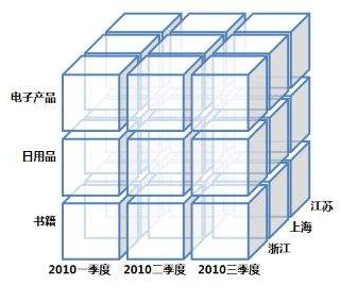

数据规约的常见种类包括维规约、数量规约和数据压缩

## 维规约
维规约的思路是减少所考虑的随机变量或属性的个数，使用的方法有属性子集选择、小波变换和主成分分析等。


### 属性子集选择
属性子集选择通过删除不相关或者冗余属性减少数据量，有以下4种方式。  
①　逐步向前选择。  
②　逐步向后删除。  
③　逐步向前选择和逐步向后删除的组合。  
④　决策树归纳。

### 小波变换
小波变换是由傅里叶变换（FFT）发展而来的，但FFT方法存在缺陷，便出现了短时傅里叶变换（STFT），最后产生了小波变换（WT）。
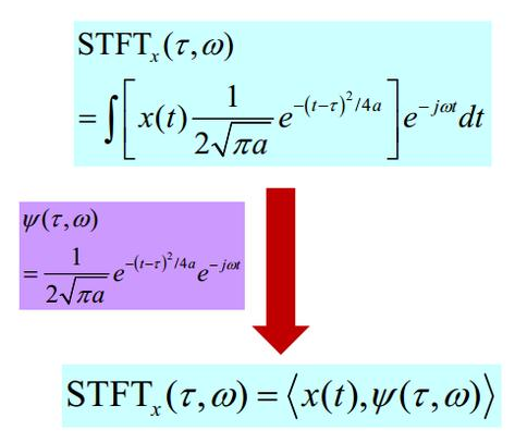

### PCA主成分分析
主成分分析是用较少的变量去解释原始数据中的大部分变量，即将许多相关性很高的变量转化成彼此相互独立或不相关的变量。
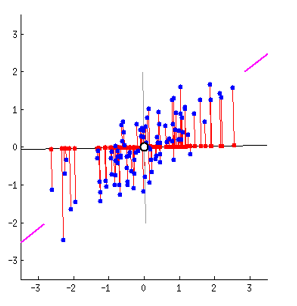

## 数量规约
数量规约，是用替代的、较小的数据表示原始数据的技术，可以是参数或非参数的，对于参数方法而言，使用模型估计数据，使得一般只需要存放模型参数而不是实际数据。

## 分类-参数化数据规约
参数化数据规约是指使用参数模型来近似原数据，最后只需要存储参数。  
参数化数据规约可以用回归模型与对数线性模型来实现。  
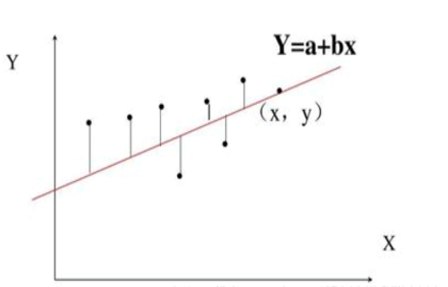

## 分类-非参数化数据规约
非参数化数据规约是指使用1个较少的数据集来近似原始数据，需要存放实际数据，包括直方图、聚类、抽样、数据立方体聚集等方法。  
（1）直方图方法即分箱，噪声光滑的一种方法就是分箱，即将数据划分为不相交的子集，并给予每个子集相同的值。  
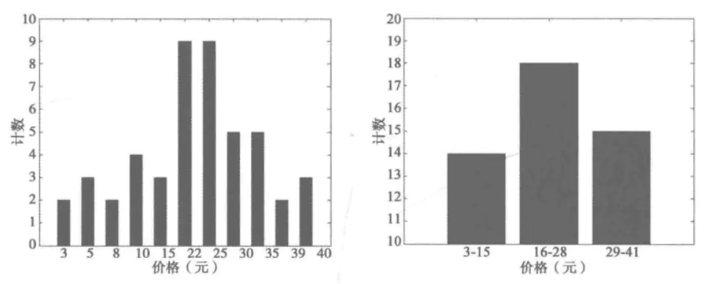

（2）聚类算法是将数据进行分群，用每个数据簇中的代表来替换实际数据，以达到数据规约的效果。  
如Kmeans聚类分析做客户分群如图所示    
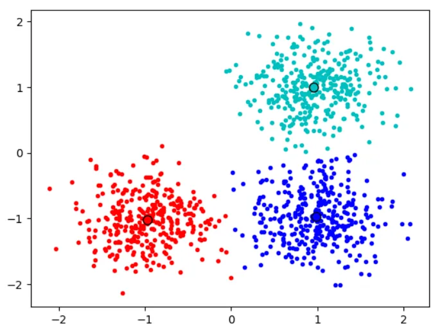

（3）抽样：通过从原数据集中按照一定规则选取随机样本（子集），来近似原数据集，实现用小数据代表大数据的过程。  
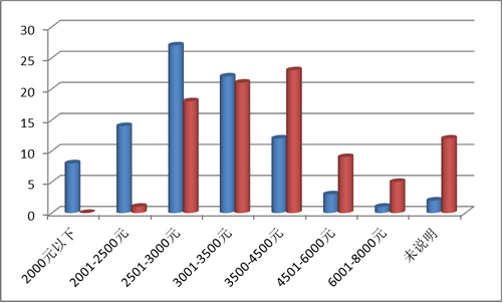

## 数据压缩
数据压缩使用变换方法得到原始数据的规约或“压缩”表示。如果数据可以在压缩后进行数据重构，而不损失信息，则该数据规约被称为无损的。如果是近似重构原数据，称为有损的。基于小波变换的数据压缩是一种非常重要的有损压缩方法。

# 数据规约操作

## 数据重塑
数据重塑指的是将数据重新排列，也叫轴向旋转。  
重塑(reshape)层次化索引，可分为最简单的stack和unstack。  
另外，unstack操作容易引入缺失数据，对DataFrame进行unstack操作时，默认情况下，unstack操作的是最内层（stack也是如此）。传入分层级别的编号或名称即可对其他级别进行unstack操作。

### 重塑层次化索引(stack&unstack)

stack：将数据的列“旋转”为行，即将二维表转化为一维表（默认操作最内层）。   
stack(self, level=-1, dropna=True)    
Level：表示操作内层索引。若设为0，表示操作外层索引，默认为-1    
dropna:表示是否将旋转后的缺失值删除，若设为True，则表示自动过滤缺失值，设置False则相反

In [2]:
df=pd.DataFrame({'A':['A0','A1','A2'],
                'B':['B0','B1','B2']})
df

,A,B
0,A0,B0
1,A1,B1
2,A2,B2


In [4]:
# 重塑df,使之具有两层行索引,将数据的列“旋转”为行
df.stack()

0  A    A0
   B    B0
1  A    A1
   B    B1
2  A    A2
   B    B2
dtype: object

unstack：将数据的行“旋转”为列，即将一维表转化为二维表（默认操作最内层）。    
unstack(self, level=-1, fill_value=None)  
Level：表示操作内层索引。若设为0，表示操作外层索引，默认为-1  
fill_value:若产生了缺失值，则可以设置这个参数用来替换NaN

In [5]:
# 将数据的行“旋转”为列
result = df.stack()

result.unstack()

,A,B
0,A0,B0
1,A1,B1
2,A2,B2


### 多层索引
多层索引，实际上就是对索引的索引，通常称作外层索引，而最原始最内层的指向数据库文件数据记录的索引叫内层索引。在对DataFrame进行unstack操作时，作为旋转轴的级别将会成为结果中的最低级别（最内层）  
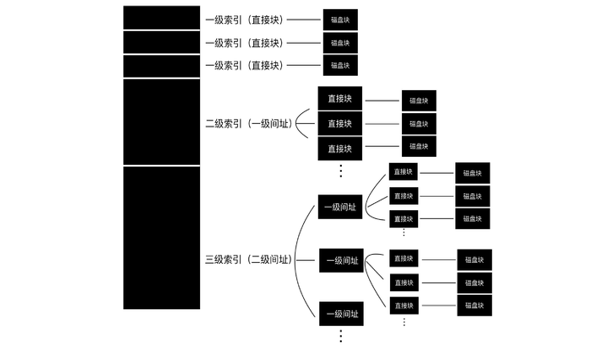

In [6]:
df2 = pd.DataFrame(np.arange(8).reshape(2, 4),
                   columns=[['A', 'A', 'B', 'B'],
                            ['A0', 'A1', 'A0', 'A1']])
df2

A     B   
  A0 A1 A0 A1
0  0  1  2  3
1  4  5  6  7

In [9]:
  # 操作内层索引  1
df2.stack()

A  B
0 A0  0  2
  A1  1  3
1 A0  4  6
  A1  5  7

In [11]:
  # 操作外层索引   0
df2.stack(level = 0)

A0  A1
0 A   0   1
  B   2   3
1 A   4   5
  B   6   7

## resample（重采样）

重采样（resample）就是将时间序列从一个频率转换到另一个频率的处理过程（**resample is a time-based groupby**）。重采样主要分为**降采样和升采样**。<br>
（1）**降采样（Downsample）**：将高频率、间隔时间短的数据**聚合**到低频率、间隔时间长的数据的过程。例如，把按照每天统计的数据，聚合为按照每月统计，即按照月分组汇总，因此，**降采样后需要聚合，即resample后，配合聚合函数**。<br>
（2）**升采样**：将低频率、间隔时间长的数据**扩展**为高频率、间隔时间短的数据的过程。例如，把按照每2h统计的数据，扩展为每1h统计。这样会产生很多空值，因此，**升采样后需要填充空值，即resample后，配合填充函数ffill()/bfill()**，不能使用fillna()。<br>
【特别注意】resample（重采样）的索引需要是Datetime,TimedeltaIndex or Period格式的。Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

| 序号 | 函数/方法              | 作用   | 示例                                                         | 主要参数                                                     | 其他说明 |
| :---- | :---------------------- | :------ | :------------------------------------------------------------ | :------------------------------------------------------------ | -------- |
| 1    | df.resample/s.resample | 重采样 | s.resample('3D',label='right').sum()<br />s.resample('H').ffill() | rule：重采样规则，相当于freq。<br />closed：'right', 'left'。左闭右开，还是左开右闭。<br />label：'right', 'left'。在降采样时，如何设置聚合值的标签。如2022-01-01到2022-01-31，按照月采样，是显示2022-01-01还是2022-01-31。 |          |

时段频率（freq参数）控制符号：Y（年）、M（月）、D（天）、H或h（小时）、T或min（分钟）、S（秒）、W（周）、Q（季度）

In [12]:
index = pd.date_range('2025-10-01', periods=90, freq='D')
values = np.random.randint(0,10, size=90)
s = pd.Series(data=values, index=index)
s

2025-10-01    4
2025-10-02    5
2025-10-03    6
2025-10-04    0
2025-10-05    1
             ..
2025-12-25    9
2025-12-26    9
2025-12-27    8
2025-12-28    4
2025-12-29    1
Freq: D, Length: 90, dtype: int32

In [13]:
# 降采样,周
s.resample(rule = 'W',label = 'right').sum()

2025-10-05    16
2025-10-12    29
2025-10-19    29
2025-10-26    27
2025-11-02    28
2025-11-09    27
2025-11-16    16
2025-11-23    18
2025-11-30    20
2025-12-07    21
2025-12-14    29
2025-12-21    19
2025-12-28    35
2026-01-04     1
Freq: W-SUN, dtype: int32

In [14]:
# 月
s.resample(rule = 'M',label = 'right').sum()

2025-10-31    121
2025-11-30     89
2025-12-31    105
Freq: ME, dtype: int32

In [15]:
# 年
s.resample('Y',label = 'left').sum()

2024-12-31    315
Freq: YE-DEC, dtype: int32

In [16]:
# 升采样，小时
s.resample('H').ffill()

2025-10-01 00:00:00    4
2025-10-01 01:00:00    4
2025-10-01 02:00:00    4
2025-10-01 03:00:00    4
2025-10-01 04:00:00    4
                      ..
2025-12-28 20:00:00    4
2025-12-28 21:00:00    4
2025-12-28 22:00:00    4
2025-12-28 23:00:00    4
2025-12-29 00:00:00    1
Freq: h, Length: 2137, dtype: int32

In [17]:
# 小时
s.resample('H').bfill()

2025-10-01 00:00:00    4
2025-10-01 01:00:00    5
2025-10-01 02:00:00    5
2025-10-01 03:00:00    5
2025-10-01 04:00:00    5
                      ..
2025-12-28 20:00:00    1
2025-12-28 21:00:00    1
2025-12-28 22:00:00    1
2025-12-28 23:00:00    1
2025-12-29 00:00:00    1
Freq: h, Length: 2137, dtype: int32

## PCA降维

主成分分析(Principal Component Analysis，PCA)是一种无监督学习的多元统计分析方法。  
**原理**：将高维数据投影到较低维空间，提取多元事物的主要因素，揭示其本质特征，可以高效地找出数据中的主要部分，将原有的复杂数据降维处理。  
**目的**：找出数据里最主要的方面代替原始数据，新的低维数据集尽可能保留原始数据的变量，是最常用的一种降维方法。  
**应用**：PCA通常用于高维数据集的探索与可视化，还可以用作数据压缩和预处理等，PCA分析被广泛应用于多个领域，比如理论物理学、气象学、心理学、生物学、化学、工程学等，在数据压缩、消除冗余和消除噪音数据等领域也有广泛的应用。  
  
  

sklearn中的PCA  
在 Python 中，主成分分析的函数位于sklearn库的decomposition中。  
class sklearn.decomposition.PCA(n_components=None, copy=True, whiten=False)